# Lag effect Analysis

### "정책 효과가 강하게 나타난 시점일수록, 모델은 더 쉽게 결과(Y)를 예측할 수 있다"
1. 정책이 효과를 발휘하면, Y(조직성과/개인결과)가 X(정책포함 정보)에 더 강하게 종속된다.
- 정책 도입 전에는 조직성과(Y)가 다양한 외적 요인에 따라 들쭉날쭉 (예측 어려움).
- 정책이 효과를 발휘하면 → 특정 정책 조건(X)에 따라 Y가 더 일관되고 예측 가능하게 변화함.
- 즉, 정책이 Y에 설명력을 부여한다.

2. 모델은 설명력 높은 관계일수록 예측 성능이 높다.
- 머신러닝 모델의 본질: 입력 X와 출력 Y 사이의 규칙성을 찾아내는 것.
- 따라서, 만약 정책 효과로 인해 X (정책포함) → Y의 인과 경로가 강해졌다면,
- 모델은 더 쉽게 일반화 가능한 패턴을 학습함.
- 결과적으로, 정확도, F1, AUC 등의 성능이 높아짐.

1. Stage 1
    - 2020년 데이터 X + 2021년 데이터 y => 모델-2020_2021
    - 2020년 데이터 X + 2023년 데이터 y => 모델-2020_2023
    => 각 모델의 퍼포먼스 측정 (강한 예측력을 보이는 모델 = 그게 결국 영향력)
    => 각 모델 해석력 지수 얻기 / 중요도에 따라서 인풋값의 가중치 다르게 줌


2. Stage 2
    - 2021년 데이터 X + 2021년 데이터 y => 모델-2021_2021
    - 2021년 데이터 X + 2023년 데이터 y => 모델-2022_2023

3. Stage 3
    - 2022년 데이터 X + 2023년 데이터 y => 모델-2022_2023

4. Stage 4
    - 2023년 데이터 X + 2023년 데이터 y => 모델-2023_2023

---

- Head말고 Work데이터를 봐야함
- Dataset: 2020 / 2021 / 2022 / 2023
- Y : Target label
    W20Q09A / W21Q09A / W22Q09A / ...

- X
    - 직원들 같은거로 하면 동일한거 거의 없음
    - 같은 회사일 필요도 없는듯

In [1]:
import matplotlib.pyplot as plt
import utils_, config, model
#from github.V1.utils_ import data_processing
import os
import numpy as np
import pandas as pd
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')


def get_all_data(year_list, file_names):
    # Expected file names (e.g., ['file1.csv', 'file2.csv'])
    file_list = os.listdir(config.path)  # All files in the directory
    dataset = {}                         # Final dictionary to store data
    year_cnt = -1                        # Counter to map years to files

    for expected_file in file_names:
        for actual_file in file_list:
            if expected_file == actual_file:
                year_cnt += 1
                current_year = year_list[year_cnt]
                print(f"{expected_file} ===> {current_year} data")

                # Load data
                df, meta = utils_.data_import(os.path.join(config.path, expected_file))

                # Store in dataset dict with year as key
                dataset[current_year] = {
                    'data': df,
                    'meta': meta
                }

    return dataset


def analyze_dataframe_step1(df: pd.DataFrame, meta, verbose):
    non_numeric_info = {}
    Meta_col = []
    total_rows = len(df)

    for idx, col in enumerate(df.columns):
        # 숫자 변환 불가능한 값 마스크
        non_numeric_mask = ~pd.to_numeric(df[col], errors='coerce').notna()
        non_numeric_count = non_numeric_mask.sum()
        nan_count = df[col].isna().sum()

        if non_numeric_count > 0:
            non_numeric_info[col] = {
                'non_numeric': non_numeric_count,
                'nan': nan_count
            }
            Meta_col.append(idx)

    # 결과 출력
    if verbose:
        print("\n\n🔍 숫자가 아닌 character가 포함된 컬럼들 및 해당 row 수:")
    for idx, (col, stats) in enumerate(non_numeric_info.items()):
        label = meta.column_labels[Meta_col[idx]]
        if verbose:
            print(f"- {col} ({label}): 숫자 아님 {stats['non_numeric']}개 / NaN {stats['nan']}개")


'''
def clean_dataframe_step1(df: pd.DataFrame, columns_to_drop: list, verbose):
    print("\n=================================\nPreprocessing\n=================================\n")
    total_rows = len(df)

    cols_to_drop = set(columns_to_drop)  # 삭제할 컬럼 집합

    for idx, col in enumerate(df.columns):
        nan_count = df[col].isna().sum()
        nan_ratio = nan_count / total_rows

        # NaN이 25% 미만이면 평균으로 대체
        if nan_count > 0 and nan_ratio < 0.25:
            try:
                mean_val = pd.to_numeric(df[col], errors='coerce').mean()
                df[col] = df[col].fillna(int(mean_val))
                if verbose:
                    print(f"→ {col}: NaN {nan_count}개 평균({int(mean_val):.2f})으로 대체 완료")
            except:
                if verbose:
                    print(f"→ {col}: 평균 계산 불가 (비숫자형 포함 등)")
                pass
        # NaN이 25% 이상이면 삭제 리스트에 추가
        elif nan_ratio >= 0.25:
            if verbose:
                print(f"→ {col}: NaN 비율 {nan_ratio:.2%}로 삭제 대상 추가")
            cols_to_drop.add(col)

    # 컬럼 삭제
    cleaned_df = df.drop(columns=list(cols_to_drop), errors='ignore')

    return cleaned_df'''


def target_variable_check(dataset, target_variable):
    for year in ['2020', '2021', '2022', '2023']:
        df, meta = dataset[year]['data'], dataset[year]['meta']
        #col_names = [f'C{year[2:]}C05_01H1', f'C{year[2:]}C05_01H2']
        #col_names = [f'C{year[2:]}C05_01H2']
        col_names = [f'W{year[2:]}{target_variable}']
        for col_name in col_names:
            nan_count = df[col_name].isna().sum()
            total = df.shape[0]
            print(f"{year} - {col_name} : NaN {nan_count}개 / 전체 {total}개 ({nan_count / total:.2%})")
            print(df[f'{col_name}'].value_counts())


###############################

def compare_company_ids_in_dataset(dataset):
    years = list(dataset.keys())
    id_sets = {}

    for year in years:
        col_name = f"W{year[2:]}ID1"
        df = dataset[year]['data']
        id_sets[year] = set(df[col_name].dropna().unique())

    for i in range(len(years)):
        for j in range(i+1, len(years)):
            y1, y2 = years[i], years[j]
            common = id_sets[y1].intersection(id_sets[y2])
            print(f"{y1} & {y2} 교집합 기업 수: {len(common)}")

    return id_sets


def get_common_company_ids_all_years(dataset):
    years = ['2020', '2021', '2022', '2023']
    id_sets = []

    for year in years:
        col_name = f"W{year[2:]}ID1"
        df = dataset[year]['data']
        ids = set(df[col_name].dropna().unique())
        id_sets.append(ids)

    common_ids = set.intersection(*id_sets)
    print(f"2020~2023 모든 연도에 공통으로 존재하는 기업 ID 수: {len(common_ids)}")

    return common_ids


def filter_dataset_by_common_ids(dataset):
    years = ['2020', '2021', '2022', '2023']
    id_sets = []

    for year in years:
        col_name = f"W{year[2:]}ID1"
        df = dataset[year]['data']  # dataset이 Series라도 동일하게 접근 가능
        ids = set(df[col_name].dropna().unique())
        id_sets.append(ids)

    common_ids = set.intersection(*id_sets)
    print(f"공통 기업 ID 개수: {len(common_ids)}")

    for year in years:
        col_name = f"W{year[2:]}ID1"
        df = dataset[year]['data']
        filtered_df = df[df[col_name].isin(common_ids)].copy()
        dataset[year]['data'] = filtered_df
        print(f"{year} 필터링 후 행 개수: {filtered_df.shape[0]}")

    return dataset


def unify_columns_by_base_name(dataset):
    years = ['2020', '2021', '2022', '2023']
    col_sets = []
    base_col_maps = {}

    print("📊 원본 컬럼 수 (with prefix):")
    for year in years:
        df = dataset[year]['data']
        prefix = f"W{year[2:]}"
        base_cols = {col[len(prefix):]: col for col in df.columns if col.startswith(prefix)}
        base_col_maps[year] = base_cols
        col_sets.append(set(base_cols.keys()))

        print(f"  - {year}: {len(df.columns)}개 컬럼 (prefix '{prefix}')")

    # 공통 base 이름 컬럼 추출
    common_base_cols = set.intersection(*col_sets)
    print(f"\n✅ 공통 base 컬럼 수: {len(common_base_cols)}개")

    # 각 연도 데이터에서 공통 컬럼만 유지
    print("\n📦 정리된 각 연도별 데이터프레임 shape:")
    for year in years:
        df = dataset[year]['data']
        prefix = f"W{year[2:]}"
        keep_cols = [base_col_maps[year][col] for col in common_base_cols]
        dataset[year]['data'] = df[keep_cols].copy()
        print(f"  - {year}: {df.shape[1]} → {len(keep_cols)}개 컬럼 유지, shape: {dataset[year]['data'].shape}")

    return dataset


def compare_company_ids(dataset_Work, dataset_Head, year):
    work_ids = dataset_Work[year]['data'][f'W{year[2:]}ID1']
    head_ids = dataset_Head[year]['data'][f'C{year[2:]}_ID1']

    print(f"🔍 {year} 데이터 비교")

    # 1. 타입 체크
    print(f"- Work ID type: {work_ids.dtype}")
    print(f"- Head ID type: {head_ids.dtype}")

    # 2. 예시 출력
    #print(f"- 예시 Work ID: {work_ids.iloc[:5].tolist()}")
    #print(f"- 예시 Head ID: {head_ids.iloc[:5].tolist()}")

    # 3. 고유 개수
    print(f"- 고유 Work 회사 수: {work_ids.nunique()}")
    print(f"- 고유 Head 회사 수: {head_ids.nunique()}")

    # 4. 교집합 확인
    overlap = set(work_ids.unique()) & set(head_ids.unique())
    print(f"- 공통 회사 ID 수: {len(overlap)}")
    print(f"- 전체 Head ID 중 비율: {len(overlap)/len(head_ids.unique()):.2%}")

    return overlap

In [2]:
def clean_dataframe_step1(df: pd.DataFrame, columns_to_drop: list, verbose=True):
    print("\n=================================\nPreprocessing\n=================================\n")
    total_rows = len(df)
    cols_to_drop = set(columns_to_drop)  # 삭제할 컬럼 집합

    for idx, col in enumerate(df.columns):
        nan_count = df[col].isna().sum()
        nan_ratio = nan_count / total_rows

        # NaN이 25% 미만이면 평균으로 대체
        if nan_count > 0 and nan_ratio < 0.25:
            try:
                mean_val = pd.to_numeric(df[col], errors='coerce').mean()
                df[col] = df[col].fillna(int(mean_val))
                if verbose:
                    print(f"→ {col}: NaN {nan_count}개 평균({int(mean_val):.2f})으로 대체 완료")
            except:
                if verbose:
                    print(f"→ {col}: 평균 계산 불가 (비숫자형 포함 등)")
                pass
        # NaN이 25% 이상이면 삭제 리스트에 추가
        elif nan_ratio >= 0.25:
            if verbose:
                print(f"→ {col}: NaN 비율 {nan_ratio:.2%}로 삭제 대상 추가")
            cols_to_drop.add(col)

    # 컬럼 삭제
    cleaned_df = df.drop(columns=list(cols_to_drop), errors='ignore')
    return cleaned_df


def clean_all_years(data_dict, columns_to_drop=[], verbose=True):
    cleaned_dict = {}

    for year in sorted(data_dict.keys()):
        print(f"\n\n🗂️ === {year}년 데이터 전처리 ===")
        df = data_dict[year]['data']
        cleaned_df = clean_dataframe_step1(df.copy(), columns_to_drop, verbose=verbose)

        # 결과 저장
        cleaned_dict[year] = {
            'data': cleaned_df,
            'meta': data_dict[year].get('meta', None)
        }

        print(f"✅ {year}년 전처리 완료: 원본 컬럼 수 {df.shape[1]} → 정제 후 컬럼 수 {cleaned_df.shape[1]}\n")

    return cleaned_dict


In [3]:
year_list = config.year               # List of years (e.g., [2018, 2020, 2022])

dataset_Work = get_all_data(year_list, config.file_names_Work)
_ = compare_company_ids_in_dataset(dataset_Work)
#utils_.see_col_idx_and_name(dataset['2020']['data'], dataset['2020']['meta'])
_ = get_common_company_ids_all_years(dataset_Work)
dataset_Work = filter_dataset_by_common_ids(dataset_Work)
target_variable_check(dataset_Work, target_variable=config.target_col)
dataset_Work = unify_columns_by_base_name(dataset_Work)

dataset_Work = clean_all_years(dataset_Work, columns_to_drop=[], verbose=True)


HCCP_2ndWave_Work_1st_v2.sav ===> 2020 data
HCCP_2ndWave_Work_2nd_v2.sav ===> 2021 data
HCCP_2ndWave_Work_3rd_v3.sav ===> 2022 data
HCCP_2ndWave_Work_4th.sav ===> 2023 data
2020 & 2021 교집합 기업 수: 455
2020 & 2022 교집합 기업 수: 439
2020 & 2023 교집합 기업 수: 408
2021 & 2022 교집합 기업 수: 471
2021 & 2023 교집합 기업 수: 426
2022 & 2023 교집합 기업 수: 446
2020~2023 모든 연도에 공통으로 존재하는 기업 ID 수: 384
공통 기업 ID 개수: 384
2020 필터링 후 행 개수: 7054
2021 필터링 후 행 개수: 7613
2022 필터링 후 행 개수: 7338
2023 필터링 후 행 개수: 8740
2020 - W20Q09A : NaN 0개 / 전체 7054개 (0.00%)
W20Q09A
3.0    2372
8.0    1682
4.0    1534
2.0     873
5.0     434
1.0     159
Name: count, dtype: int64
2021 - W21Q09A : NaN 0개 / 전체 7613개 (0.00%)
W21Q09A
-8.0    2331
 3.0    2318
 4.0    1511
 2.0     907
 5.0     369
 1.0     177
Name: count, dtype: int64
2022 - W22Q09A : NaN 0개 / 전체 7338개 (0.00%)
W22Q09A
3.0    2263
8.0    1922
4.0    1436
2.0     893
5.0     501
1.0     323
Name: count, dtype: int64
2023 - W23Q09A : NaN 0개 / 전체 8740개 (0.00%)
W23Q09A
3.0    4008
4.0    203

In [4]:
dataset_Head = get_all_data(year_list, config.file_names_Head)
#for year in year_list:
#    compare_company_ids(dataset_Work, dataset_Head, year)


HCCP_2ndWave_Head_1st(최종).sav ===> 2020 data
HCCP_2ndWave_Head_2nd(최종).sav ===> 2021 data
HCCP_2ndWave_Head_3rd(최종).sav ===> 2022 data
HCCP_2ndWave_Head_4th.sav ===> 2023 data


✅ Year: 2020 | Merged shape: (7054, 125) | work shape: (7054, 127) | head shape: (500, 2)
✅ Year: 2020 | Merged shape: (7054, 125) | work shape: (7054, 127) | head shape: (500, 2)
	 (1918, 124) (1918,)
	 (1697, 124) (1697,)
✅ Year: 2021 | Merged shape: (7613, 126) | work shape: (7613, 128) | head shape: (500, 2)
✅ Year: 2021 | Merged shape: (7613, 126) | work shape: (7613, 128) | head shape: (500, 2)
	 (1989, 125) (1989,)
	 (1640, 125) (1640,)
✅ Year: 2022 | Merged shape: (7338, 139) | work shape: (7338, 141) | head shape: (500, 2)
	 (1604, 138) (1604,)
✅ Year: 2023 | Merged shape: (8740, 124) | work shape: (8740, 126) | head shape: (500, 2)
	 (2094, 123) (2094,)

🧪 Processing: 2020 ➝ 2021
Original class distribution:
1.0    1247
0.0     671
Name: count, dtype: int64
Resampled class distribution:
0.0    957
1.0    957
Name: count, dtype: int64
XGBoost Accuracy ========>  83.07291666666666 %

🧪 Processing: 2020 ➝ 2023
Original class distribution:
1.0    1388
0.0     309
Name: count, dty

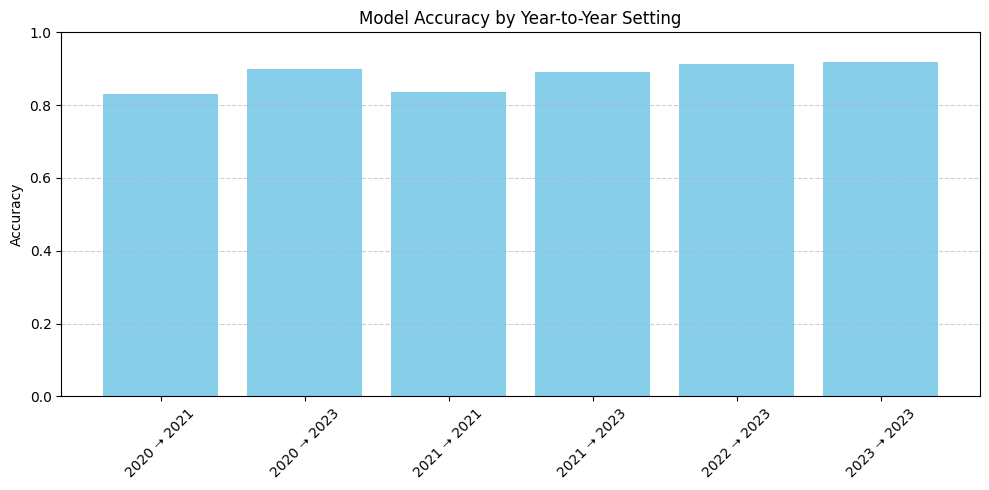

In [5]:
def merge_worker_head_labels(dataset_Work, dataset_Head, year_w, year_h):
    # Define ID column names
    label_col=f'C{year_h[2:]}C05_01H2'
    work_id_col = f'W{year_w[2:]}ID1'
    head_id_col = f'C{year_h[2:]}_ID1'
    worker_id_col = f'W{year_w[2:]}ID2'
    work_company_id_col = f'W{year_w[2:]}ID3'

    # Extract data
    df_work = dataset_Work[year_w]['data']
    df_head = dataset_Head[year_h]['data']

    # Select only ID and label column from head
    df_head_selected = df_head[[head_id_col, label_col]].copy()

    # Merge on company ID
    merged = pd.merge(df_work, df_head_selected, left_on=work_id_col, right_on=head_id_col, how='inner')

    # Drop ID columns from features
    merged = merged.drop(columns=[work_id_col, head_id_col, worker_id_col, work_company_id_col], errors='ignore')
    #y = merged[label_col]

    #print(f"✅ Year: {year} | Merged shape: {merged.shape} | X shape: {X.shape} | y shape: {y.shape}")
    print(f"✅ Year: {year} | Merged shape: {merged.shape} | work shape: {df_work.shape} | head shape: {df_head_selected.shape}")

    return merged, label_col #, X, y


def clean_target_classes(df: pd.DataFrame, target_col) -> pd.DataFrame:

    df = df[df[target_col] != 3].copy()  # 3인 행 삭제
    df = df[df[target_col] != 8].copy()  # 8인 행 삭제
    df = df[df[target_col] != -8].copy()  # -8인 행 삭제
    df.loc[df[target_col].isin([1, 2]), target_col] = 0 # 1,2 -> 0
    df.loc[df[target_col].isin([4, 5]), target_col] = 1 # 4,5 -> 1
    y = df[target_col]

    df = df.drop(columns=[target_col], errors='ignore')

    return df.reset_index(drop=True), np.array(y)


from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score


def train_evaluate_model(X, y, description=''):
    print(f"\n🧪 Processing: {description}")
    print(f"Original class distribution:\n{pd.Series(y).value_counts()}")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Apply SMOTE + Tomek (oversample + undersample)
    smt = SMOTETomek(random_state=42)
    X_resampled, y_resampled = smt.fit_resample(X_train, y_train)

    print(f"Resampled class distribution:\n{pd.Series(y_resampled).value_counts()}")

    # Train
    model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    model.fit(X_resampled, y_resampled)

    # Evaluate
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print("XGBoost Accuracy ========> ", accuracy * 100, "%")
    return accuracy




results_by_year = {}
for year in ['2020', '2021', '2022', '2023']:
    if year == '2021' or '2023':
        if year == '2021':
            df1, label_col1 = merge_worker_head_labels(dataset_Work, dataset_Head, year_w=year, year_h='2021')
            df2, label_col2 = merge_worker_head_labels(dataset_Work, dataset_Head, year_w=year, year_h='2023')
            df_21_21, y_21_21 = clean_target_classes(df1, target_col=label_col1)
            df_21_23, y_21_23 = clean_target_classes(df2, target_col=label_col2)
            print("\t", df_21_21.shape, y_21_21.shape)#, pd.Series(y_21_21).value_counts())
            print("\t", df_21_23.shape, y_21_23.shape)#, pd.Series(y_21_23).value_counts())

        elif year == '2023':
            df1, label_col1 = merge_worker_head_labels(dataset_Work, dataset_Head, year_w=year, year_h='2023')
            df_23_23, y_23_23 = clean_target_classes(df1, target_col=label_col1)
            print("\t", df_23_23.shape, y_23_23.shape)#, pd.Series(y_23_23).value_counts())

    if year == '2020' or '2022':
        if year == '2020':
            df1, label_col1 = merge_worker_head_labels(dataset_Work, dataset_Head, year_w=year, year_h='2021')
            df2, label_col2 = merge_worker_head_labels(dataset_Work, dataset_Head, year_w=year, year_h='2023')
            df_20_21, y_20_21 = clean_target_classes(df1, target_col=label_col1)
            df_20_23, y_20_23 = clean_target_classes(df2, target_col=label_col2)
            print("\t", df_20_21.shape, y_20_21.shape)#, pd.Series(y_20_21).value_counts())
            print("\t", df_20_23.shape, y_20_23.shape)#, pd.Series(y_20_23).value_counts())

        elif year == '2022':
            df1, label_col1 = merge_worker_head_labels(dataset_Work, dataset_Head, year_w=year, year_h='2023')
            df_22_23, y_22_23 = clean_target_classes(df1, target_col=label_col1)
            print("\t", df_22_23.shape, y_22_23.shape)#, pd.Series(y_22_23).value_counts())

    #results_by_year[year] = {'merged': merged_df, 'X': X, 'y': y}
import matplotlib.pyplot as plt

# Define the datasets and their labels
dataset_pairs = {
    "2020 ➝ 2021": (df_20_21, y_20_21),
    "2020 ➝ 2023": (df_20_23, y_20_23),
    "2021 ➝ 2021": (df_21_21, y_21_21),
    "2021 ➝ 2023": (df_21_23, y_21_23),
    "2022 ➝ 2023": (df_22_23, y_22_23),
    "2023 ➝ 2023": (df_23_23, y_23_23),
}

# Store accuracies
acc_dict = {}

# Evaluate and store
for desc, (X, y) in dataset_pairs.items():
    acc = train_evaluate_model(X, y, description=desc)
    acc_dict[desc] = acc

# Plotting
plt.figure(figsize=(10, 5))
plt.bar(acc_dict.keys(), acc_dict.values(), color='skyblue')
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy by Year-to-Year Setting")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



In [6]:
# Function: Train + SHAP analysis
import shap

def train_and_analyze(X, Y, label=""):
    y = Y.ravel() if isinstance(Y, np.ndarray) else Y.values.ravel()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train model
    model = XGBClassifier()
    model.fit(X_train, y_train)

    # SHAP analysis
    explainer = shap.Explainer(model)
    shap_values = explainer(X_test)
    importance = pd.DataFrame({
        'feature': X.columns,
        'importance': shap_values.values.mean(axis=0)
    }).sort_values(by='importance', ascending=False)

    return model, importance

model_20_21, imp_20_21 = train_and_analyze(df_20_21, y_20_21, label="2020_2021")
model_20_23, imp_20_23 = train_and_analyze(df_20_23, y_20_23, label="2020_2023")
model_21_21, imp_21_21 = train_and_analyze(df_21_21, y_21_21, label="2021_2021")
model_21_23, imp_21_23 = train_and_analyze(df_21_23, y_21_23, label="2021_2023")

print("\n📊 Policy-related feature importance by year:")
for year, imp in zip(['2020', '2020', '2021', '2021'], [imp_20_21, imp_20_23, imp_21_21, imp_21_23]):
    val = imp.query(f"feature == 'W{year[2:]}Q10B'")['importance'].values
    print(f"{year}: {val[0] if len(val) > 0 else 'Not Found'}")


📊 Policy-related feature importance by year:
2020: 0.002245148876681924
2020: 0.00823393277823925
2021: 0.0034610817674547434
2021: 0.0002336237666895613


In [8]:
df_20_21

,W20Q16C1,W20Q10B,W20Q081E,W20Q081B,W20Q27C,W20DQ01,W20Q21,W20Q14A,W20Q05B,W20Q09C,...,W20Q25A,W20Q301,W20Q25I,W20Q18B,W20Q23D,W20Q25C,W20Q15D1,W20Q01B,W20Q081C,W20Q07
0,2.0,1.0,5.0,4.0,3.0,1.0,2.0,5.0,3.0,4.0,...,5.0,40.0,2.0,7.0,4.0,4.0,1.0,3.0,4.0,2.0
1,2.0,2.0,3.0,3.0,1.0,2.0,3.0,3.0,1.0,2.0,...,2.0,40.0,4.0,1.0,2.0,2.0,2.0,1.0,3.0,2.0
2,2.0,2.0,3.0,3.0,2.0,2.0,1.0,3.0,4.0,3.0,...,3.0,40.0,2.0,1.0,3.0,3.0,2.0,4.0,3.0,4.0
3,2.0,2.0,3.0,2.0,2.0,2.0,2.0,1.0,5.0,3.0,...,2.0,40.0,5.0,1.0,3.0,4.0,2.0,5.0,3.0,3.0
4,2.0,1.0,3.0,3.0,4.0,1.0,2.0,3.0,8.0,3.0,...,4.0,40.0,4.0,3.0,3.0,3.0,2.0,8.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1913,2.0,2.0,3.0,3.0,4.0,1.0,1.0,3.0,8.0,8.0,...,2.0,40.0,3.0,4.0,2.0,2.0,2.0,8.0,4.0,2.0
1914,2.0,1.0,3.0,3.0,3.0,1.0,2.0,4.0,3.0,8.0,...,3.0,40.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,2.0
1915,2.0,1.0,3.0,3.0,3.0,1.0,2.0,3.0,2.0,8.0,...,3.0,40.0,3.0,3.0,3.0,3.0,2.0,2.0,3.0,2.0
1916,2.0,1.0,3.0,3.0,5.0,1.0,2.0,3.0,3.0,8.0,...,3.0,40.0,4.0,3.0,3.0,4.0,1.0,3.0,4.0,2.0


In [7]:
'''W20ID1 기업id
W20ID2 근로자id
W20ID3 기업&근로자id
W20IND1 산업분류'''

'W20ID1 기업id\nW20ID2 근로자id\nW20ID3 기업&근로자id\nW20IND1 산업분류'

In [ ]:
다른 년도 레이블을 주기가 어렵다
방법 1. Head 데이터로 레이블을 준다 = 같은 회사면 동일한 레이블을 준다 => 그러면 또 엄청나게 떨어져 나감; 70%
방법 2. 동년에만 한다 =

=> 헤드데이터로 representative 레이블링을 준다!